# Fusion_GRU_2DCNN — Georgia Evaluation

Evaluation notebook — loads `best_model.pt`, rebuilds test split, computes metrics & XAI.

## 1 · Imports & config

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pickle, pathlib
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import f1_score, multilabel_confusion_matrix, roc_auc_score
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

plt.rcParams.update({"figure.dpi": 130, "font.size": 11})
sns.set_style("whitegrid")

SEED        = 42
torch.manual_seed(SEED); np.random.seed(SEED)
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else
                            "mps"  if torch.backends.mps.is_available() else "cpu")
print("Device:", DEVICE)

CLASS_NAMES = ["MI", "STTC", "CD", "HYP"]
NUM_CLASSES = 4
NORM_CAP    = 4000
BATCH_SIZE  = 64
THRESHOLD   = 0.5
COLORS      = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12"]
LEAD_NAMES  = ["I","II","III","aVR","aVL","aVF","V1","V2","V3","V4","V5","V6"]


Device: cuda


## 2 · Load data & rebuild test split

In [2]:

def load_pkl(p):
    with open(p, "rb") as f: return pickle.load(f)

DATA_DIR = pathlib.Path("../../GeorgiaECG")
CKPT_DIR = pathlib.Path("checkpoints")

X_all = load_pkl(DATA_DIR/"X_georgia.pickle").astype(np.float32)
y_all = load_pkl(DATA_DIR/"y_georgia.pickle").astype(np.float32)

rng         = np.random.default_rng(SEED)
norm_idx    = np.where(y_all.sum(1) == 0)[0]
disease_idx = np.where(y_all.sum(1) >  0)[0]
if len(norm_idx) > NORM_CAP:
    norm_idx = rng.choice(norm_idx, NORM_CAP, replace=False)
bal_idx      = np.concatenate([disease_idx, norm_idx])
X_bal, y_bal = X_all[bal_idx], y_all[bal_idx]

norm_col = (y_bal.sum(1) == 0).astype(np.float32)[:, None]
y_strat  = np.concatenate([y_bal, norm_col], axis=1)
msss1    = MultilabelStratifiedShuffleSplit(1, test_size=0.15,  random_state=SEED)
tv_idx, te_idx = next(msss1.split(X_bal, y_strat))
y_tv_str = np.concatenate([y_bal[tv_idx],
                            (y_bal[tv_idx].sum(1)==0).astype(np.float32)[:,None]], axis=1)
msss2    = MultilabelStratifiedShuffleSplit(1, test_size=0.176, random_state=SEED)
tr2, va2 = next(msss2.split(X_bal[tv_idx], y_tv_str))

X_train_s, y_train_s = X_bal[tv_idx][tr2], y_bal[tv_idx][tr2]
X_val_s,   y_val_s   = X_bal[tv_idx][va2], y_bal[tv_idx][va2]
X_test_s,  y_test_s  = X_bal[te_idx],      y_bal[te_idx]
print(f"Train {len(X_train_s)} | Val {len(X_val_s)} | Test {len(X_test_s)}")


Train 7229 | Val 1548 | Test 1567


## 3 · Model — load checkpoint

In [3]:
class CBAM(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.ca_avg = nn.AdaptiveAvgPool2d(1); self.ca_max = nn.AdaptiveMaxPool2d(1)
        self.ca_fc  = nn.Sequential(nn.Linear(channels, channels//reduction), nn.ReLU(),
                                     nn.Linear(channels//reduction, channels))
        self.sa_conv = nn.Conv2d(2, 1, kernel_size=7, padding=3, bias=False)
    def forward(self, x):
        avg = self.ca_avg(x).flatten(1); mx = self.ca_max(x).flatten(1)
        ca  = torch.sigmoid(self.ca_fc(avg) + self.ca_fc(mx)).unsqueeze(-1).unsqueeze(-1)
        x   = x * ca
        sa  = torch.sigmoid(self.sa_conv(torch.cat([x.mean(1,keepdim=True), x.max(1,keepdim=True)[0]], dim=1)))
        return x * sa

class GRU_2DCNN_Fusion(nn.Module):
    def __init__(self, n_classes=NUM_CLASSES, gru_hidden=128, cnn_ch=64):
        super().__init__()
        self.gru_cnn = nn.Sequential(
            nn.Conv1d(12,64,7,padding=3), nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(4),
            nn.Conv1d(64,128,5,padding=2), nn.BatchNorm1d(128), nn.ReLU(), nn.MaxPool1d(5))
        self.bigru = nn.GRU(128, gru_hidden, num_layers=2, bidirectional=True,
                             batch_first=True, dropout=0.2)
        def conv_block(ci, co):
            return nn.Sequential(nn.Conv2d(ci,co,3,padding=1), nn.BatchNorm2d(co), nn.ReLU(), nn.MaxPool2d(2))
        self.cnn      = nn.Sequential(conv_block(12,cnn_ch), conv_block(cnn_ch,cnn_ch*2), conv_block(cnn_ch*2,cnn_ch*4))
        self.cbam     = CBAM(cnn_ch*4)
        self.cnn_pool = nn.AdaptiveAvgPool2d(1)
        self.fusion   = nn.Sequential(nn.Dropout(0.3),
                                       nn.Linear(gru_hidden*2+cnn_ch*4, 128), nn.ReLU(),
                                       nn.Dropout(0.2), nn.Linear(128, n_classes))
    def forward(self, x_raw, x_spec):
        g, _ = self.bigru(self.gru_cnn(x_raw).permute(0,2,1))
        c    = self.cnn_pool(self.cbam(self.cnn(x_spec))).flatten(1)
        return self.fusion(torch.cat([g.mean(1), c], dim=1))

model = GRU_2DCNN_Fusion().to(DEVICE)
ckpt  = torch.load(CKPT_DIR/"best_model.pt", map_location=DEVICE)
model.load_state_dict(ckpt); model.eval()
print(f"Loaded checkpoint  |  params: {sum(p.numel() for p in model.parameters()):,}")


Loaded checkpoint  |  params: 993,142


## 4 · Inference on val & test

In [4]:

from scipy.signal import stft as scipy_stft

def ecg_to_spec(ecg, nperseg=64, noverlap=48, img_size=64):
    specs = []
    for lead in ecg:
        _, _, Z = scipy_stft(lead, nperseg=nperseg, noverlap=noverlap)
        mag = np.log1p(np.abs(Z)).astype(np.float32)
        t   = torch.tensor(mag).unsqueeze(0).unsqueeze(0)
        t   = F.interpolate(t, size=(img_size,img_size), mode="bilinear", align_corners=False)
        specs.append(t.squeeze().numpy())
    s = np.stack(specs).astype(np.float32); mn, mx = s.min(), s.max()
    return (s - mn) / (mx - mn + 1e-8)

class ECGFusionDataset(Dataset):
    def __init__(self, X, y):
        self.X=torch.from_numpy(X).float(); self.y=torch.from_numpy(y).float()
    def __len__(self): return len(self.X)
    def __getitem__(self, i):
        return self.X[i], torch.from_numpy(ecg_to_spec(self.X[i].numpy())), self.y[i]

kw = dict(batch_size=BATCH_SIZE, num_workers=0, pin_memory=True)
val_loader = DataLoader(ECGFusionDataset(X_val_s,  y_val_s),  shuffle=False, **kw)
te_loader  = DataLoader(ECGFusionDataset(X_test_s, y_test_s), shuffle=False, **kw)

def infer(loader, mdl):
    mdl.eval(); probs, tgts = [], []
    with torch.no_grad():
        for xr, xs, yb in loader:
            probs.append(torch.sigmoid(mdl(xr.to(DEVICE), xs.to(DEVICE))).cpu().numpy())
            tgts.append(yb.numpy())
    return np.concatenate(probs), np.concatenate(tgts)

val_probs,  val_tgts  = infer(val_loader, model)
test_probs, test_tgts = infer(te_loader,  model)
print(f"Val {val_probs.shape}  Test {test_probs.shape}")


Val (1548, 4)  Test (1567, 4)


## 5 · Threshold tuning (val set — no test leakage)

In [5]:

def compute_metrics(probs, targets, threshold=0.5):
    thr = np.array(threshold) if not np.isscalar(threshold) else threshold
    preds = (probs >= thr).astype(int)
    mcm   = multilabel_confusion_matrix(targets.astype(int), preds)
    res   = {}
    for i, cls in enumerate(CLASS_NAMES):
        tn, fp, fn, tp = mcm[i].ravel()
        res[cls] = dict(
            sensitivity = tp/(tp+fn+1e-8),
            specificity = tn/(tn+fp+1e-8),
            accuracy    = (tp+tn)/(tp+tn+fp+fn+1e-8),
            f1          = 2*tp/(2*tp+fp+fn+1e-8),
        )
    for m in ("sensitivity","specificity","accuracy","f1"):
        res[f"macro_{m}"] = np.mean([res[c][m] for c in CLASS_NAMES])
    return res

def print_metrics(m, label=""):
    if label: print(f"\n{'─'*55}\n  {label}\n{'─'*55}")
    print(f"{'Class':<6} {'Sensitivity':>12} {'Specificity':>12} {'Accuracy':>10} {'F1':>8}")
    print("─"*52)
    for cls in CLASS_NAMES:
        print(f"{cls:<6} {m[cls]['sensitivity']:>12.4f} {m[cls]['specificity']:>12.4f} "
              f"{m[cls]['accuracy']:>10.4f} {m[cls]['f1']:>8.4f}")
    print("─"*52)
    print(f"{'Macro':<6} {m['macro_sensitivity']:>12.4f} {m['macro_specificity']:>12.4f} "
          f"{m['macro_accuracy']:>10.4f} {m['macro_f1']:>8.4f}")
    try:
        auc = roc_auc_score(test_tgts, test_probs, average="macro")
        print(f"  Macro AUC: {auc:.4f}")
    except: pass


In [6]:

grid = np.arange(0.05, 0.95, 0.01)
best_t, curves = {}, {}
print("Threshold tuning on val set (no test leakage):")
print(f"{'Class':<6} {'Best t':>8} {'F1@0.5':>9} {'F1@best':>9}")
print("-"*36)
for i, cls in enumerate(CLASS_NAMES):
    f1s   = [f1_score(val_tgts[:,i], (val_probs[:,i]>=t).astype(int), zero_division=0) for t in grid]
    bt    = grid[np.argmax(f1s)]
    f50   = f1_score(val_tgts[:,i], (val_probs[:,i]>=0.5).astype(int), zero_division=0)
    best_t[cls] = bt; curves[cls] = f1s
    print(f"{cls:<6} {bt:>8.2f} {f50:>9.4f} {max(f1s):>9.4f}")

tuned_arr  = np.array([best_t[c] for c in CLASS_NAMES])
test_m_def = compute_metrics(test_probs, test_tgts, 0.5)
test_m_tun = compute_metrics(test_probs, test_tgts, tuned_arr)

print("\nTest — default vs tuned:")
print(f"{'Class':<6} {'F1@0.5':>8} {'F1@tuned':>10} {'Δ':>7}")
print("-"*30)
for cls in CLASS_NAMES:
    d = test_m_tun[cls]['f1'] - test_m_def[cls]['f1']
    print(f"{cls:<6} {test_m_def[cls]['f1']:>8.4f} {test_m_tun[cls]['f1']:>10.4f} {d:>+6.4f}")
d_mac = test_m_tun['macro_f1'] - test_m_def['macro_f1']
print(f"{'Macro':<6} {test_m_def['macro_f1']:>8.4f} {test_m_tun['macro_f1']:>10.4f} {d_mac:>+6.4f}")


Threshold tuning on val set (no test leakage):
Class    Best t    F1@0.5   F1@best
------------------------------------
MI         0.60    0.6077    0.6969
STTC       0.52    0.7445    0.7521
CD         0.48    0.7683    0.7765
HYP        0.49    0.6584    0.6696

Test — default vs tuned:
Class    F1@0.5   F1@tuned       Δ
------------------------------
MI       0.6184     0.6777 +0.0594
STTC     0.7291     0.7368 +0.0077
CD       0.7561     0.7560 -0.0001
HYP      0.6656     0.6705 +0.0049
Macro    0.6923     0.7103 +0.0180


## 6 · Metrics & visualisations


───────────────────────────────────────────────────────
  Test — tuned thresholds
───────────────────────────────────────────────────────
Class   Sensitivity  Specificity   Accuracy       F1
────────────────────────────────────────────────────
MI           0.8095       0.9493     0.9381   0.6777
STTC         0.7655       0.8247     0.8034   0.7368
CD           0.8336       0.7904     0.8060   0.7560
HYP          0.7857       0.6650     0.7103   0.6705
────────────────────────────────────────────────────
Macro        0.7986       0.8074     0.8145   0.7103
  Macro AUC: 0.8825


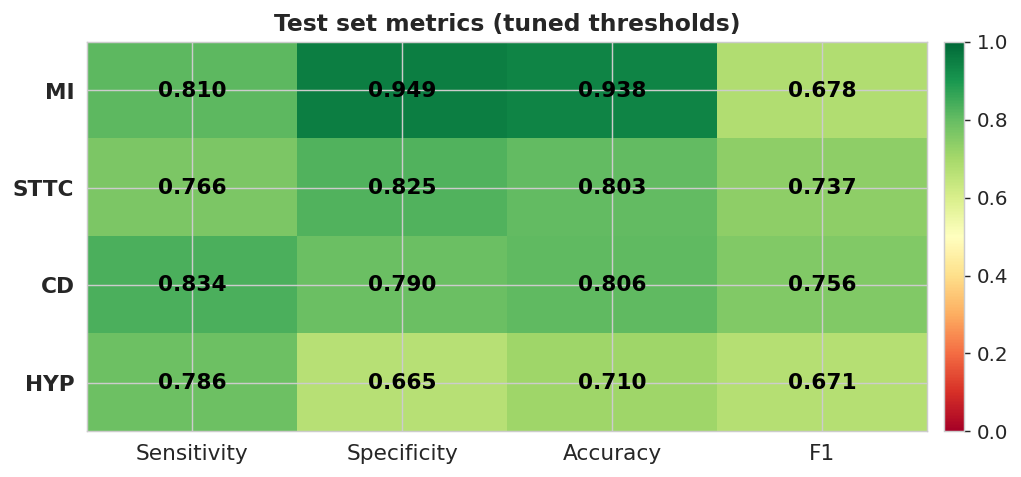

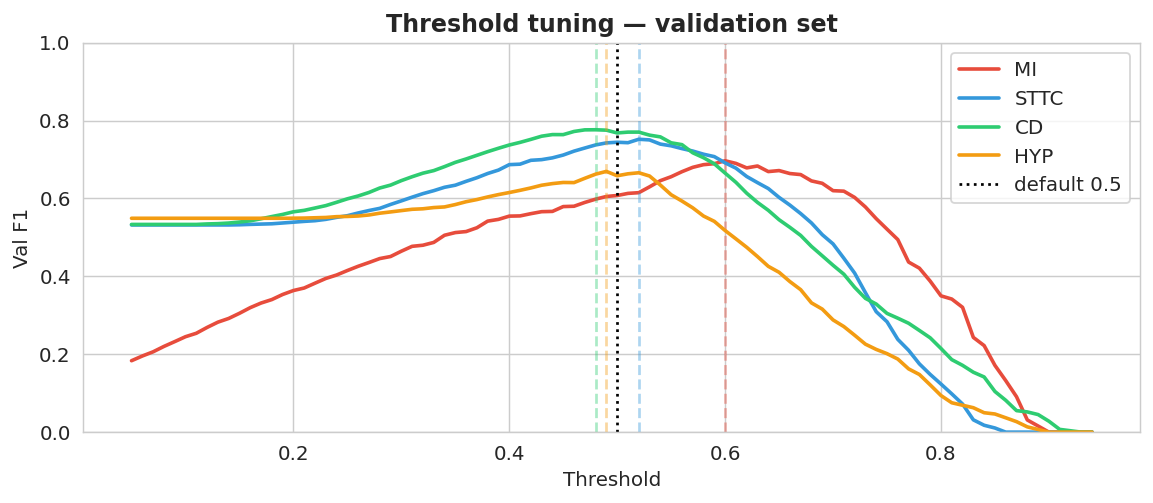

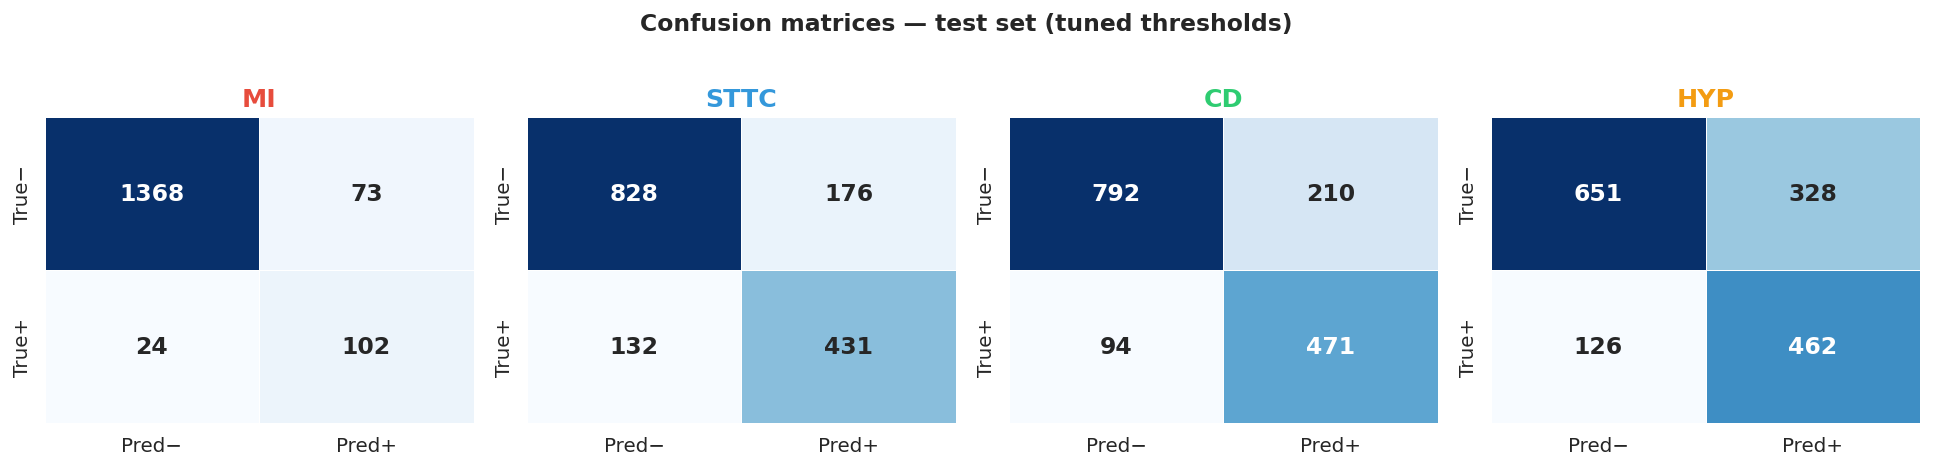

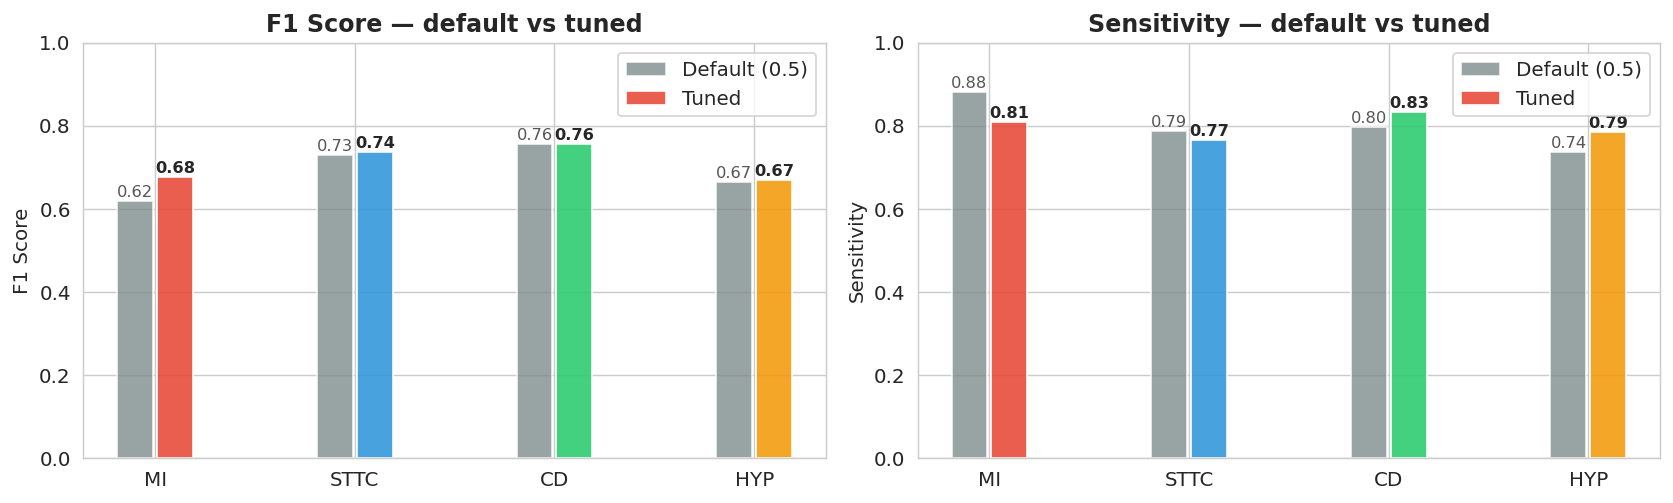

In [7]:
print_metrics(test_m_tun, "Test — tuned thresholds")

# ── 1. Metric heatmap ─────────────────────────────────────────────────────────
keys   = ["sensitivity","specificity","accuracy","f1"]
labels = ["Sensitivity","Specificity","Accuracy","F1"]
data   = np.array([[test_m_tun[c][k] for k in keys] for c in CLASS_NAMES])

fig, ax = plt.subplots(figsize=(8, 3.8))
im = ax.imshow(data, vmin=0, vmax=1, cmap="RdYlGn", aspect="auto")
ax.set_xticks(range(4)); ax.set_xticklabels(labels, fontsize=12)
ax.set_yticks(range(4)); ax.set_yticklabels(CLASS_NAMES, fontsize=12, fontweight="bold")
for i in range(4):
    for j in range(4):
        v = data[i,j]
        ax.text(j, i, f"{v:.3f}", ha="center", va="center",
                fontsize=12, fontweight="bold", color="white" if v < 0.45 else "black")
ax.set_title("Test set metrics (tuned thresholds)", fontweight="bold", fontsize=13)
plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
plt.tight_layout(); plt.savefig(CKPT_DIR/"metrics_heatmap.png", bbox_inches="tight"); plt.show()

# ── 2. Threshold–F1 curves ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
for cls, col in zip(CLASS_NAMES, COLORS):
    ax.plot(grid, curves[cls], color=col, linewidth=2, label=cls)
    ax.axvline(best_t[cls], color=col, linestyle="--", alpha=0.4)
ax.axvline(0.5, color="black", linestyle=":", linewidth=1.5, label="default 0.5")
ax.set_xlabel("Threshold"); ax.set_ylabel("Val F1"); ax.set_ylim(0, 1)
ax.set_title("Threshold tuning — validation set", fontweight="bold")
ax.legend(); plt.tight_layout()
plt.savefig(CKPT_DIR/"threshold_curves.png", bbox_inches="tight"); plt.show()

# ── 3. Confusion matrices ─────────────────────────────────────────────────────
preds_tuned = (test_probs >= tuned_arr).astype(int)
mcm = multilabel_confusion_matrix(test_tgts.astype(int), preds_tuned)
fig, axes = plt.subplots(1, 4, figsize=(15, 3.5))
for i, (ax, cls, col) in enumerate(zip(axes, CLASS_NAMES, COLORS)):
    sns.heatmap(mcm[i], annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False,
                linewidths=0.5, annot_kws={"size": 13, "weight": "bold"},
                xticklabels=["Pred−", "Pred+"], yticklabels=["True−", "True+"])
    ax.set_title(cls, fontweight="bold", color=col, fontsize=14)
plt.suptitle("Confusion matrices — test set (tuned thresholds)",
             fontweight="bold", fontsize=13, y=1.02)
plt.tight_layout(); plt.savefig(CKPT_DIR/"confusion_matrices.png", bbox_inches="tight"); plt.show()

# ── 4. F1 & Sensitivity bar chart ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
x = np.arange(4); w = 0.2
for ax, (metric, label) in zip(axes, [("f1","F1 Score"), ("sensitivity","Sensitivity")]):
    vd = [test_m_def[c][metric] for c in CLASS_NAMES]
    vt = [test_m_tun[c][metric] for c in CLASS_NAMES]
    ax.bar(x - w/2, vd, w*0.9, label="Default (0.5)", color="#7f8c8d", alpha=0.8)
    ax.bar(x + w/2, vt, w*0.9, label="Tuned",         color=COLORS,    alpha=0.9)
    ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES, fontsize=11)
    ax.set_ylim(0, 1); ax.set_ylabel(label)
    ax.set_title(f"{label} — default vs tuned", fontweight="bold")
    ax.legend()
    for xi, (a, b) in enumerate(zip(vd, vt)):
        ax.text(xi-w/2, a+0.01, f"{a:.2f}", ha="center", fontsize=9, color="#555")
        ax.text(xi+w/2, b+0.01, f"{b:.2f}", ha="center", fontsize=9, fontweight="bold")
plt.tight_layout(); plt.savefig(CKPT_DIR/"bar_metrics.png", bbox_inches="tight"); plt.show()


## 7 · XAI

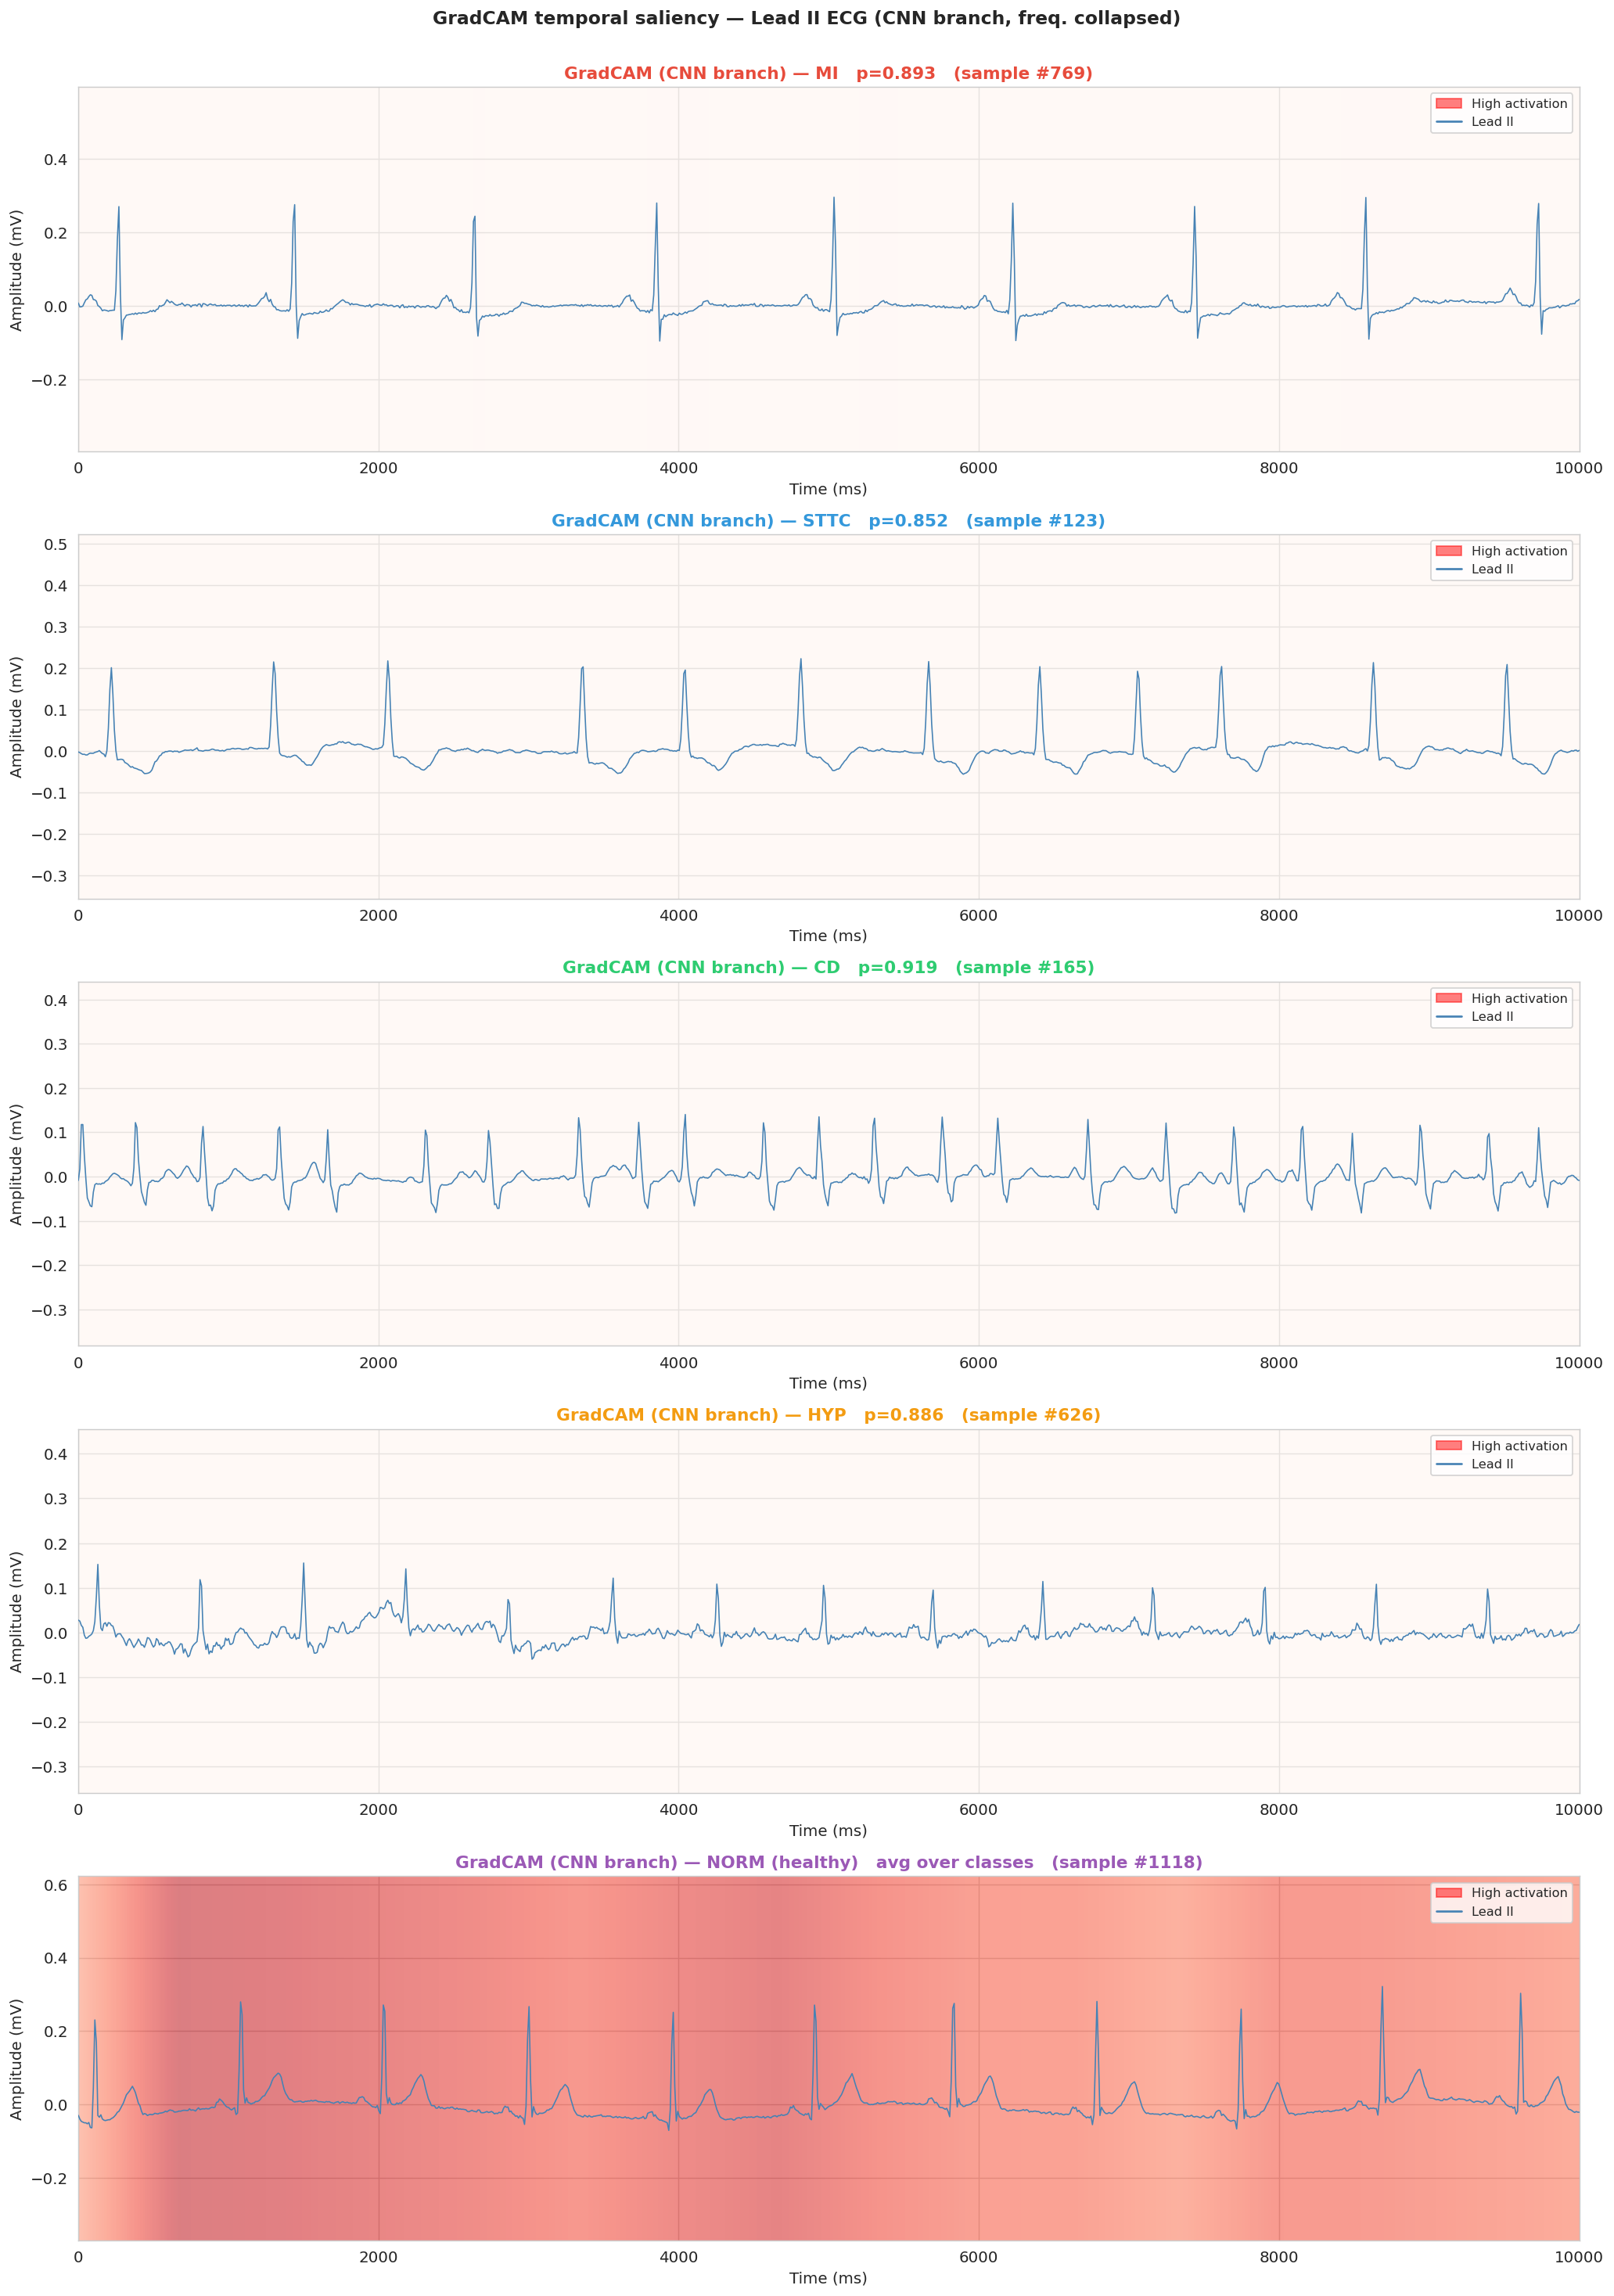

GRU attribution for MI (sample #769) ...


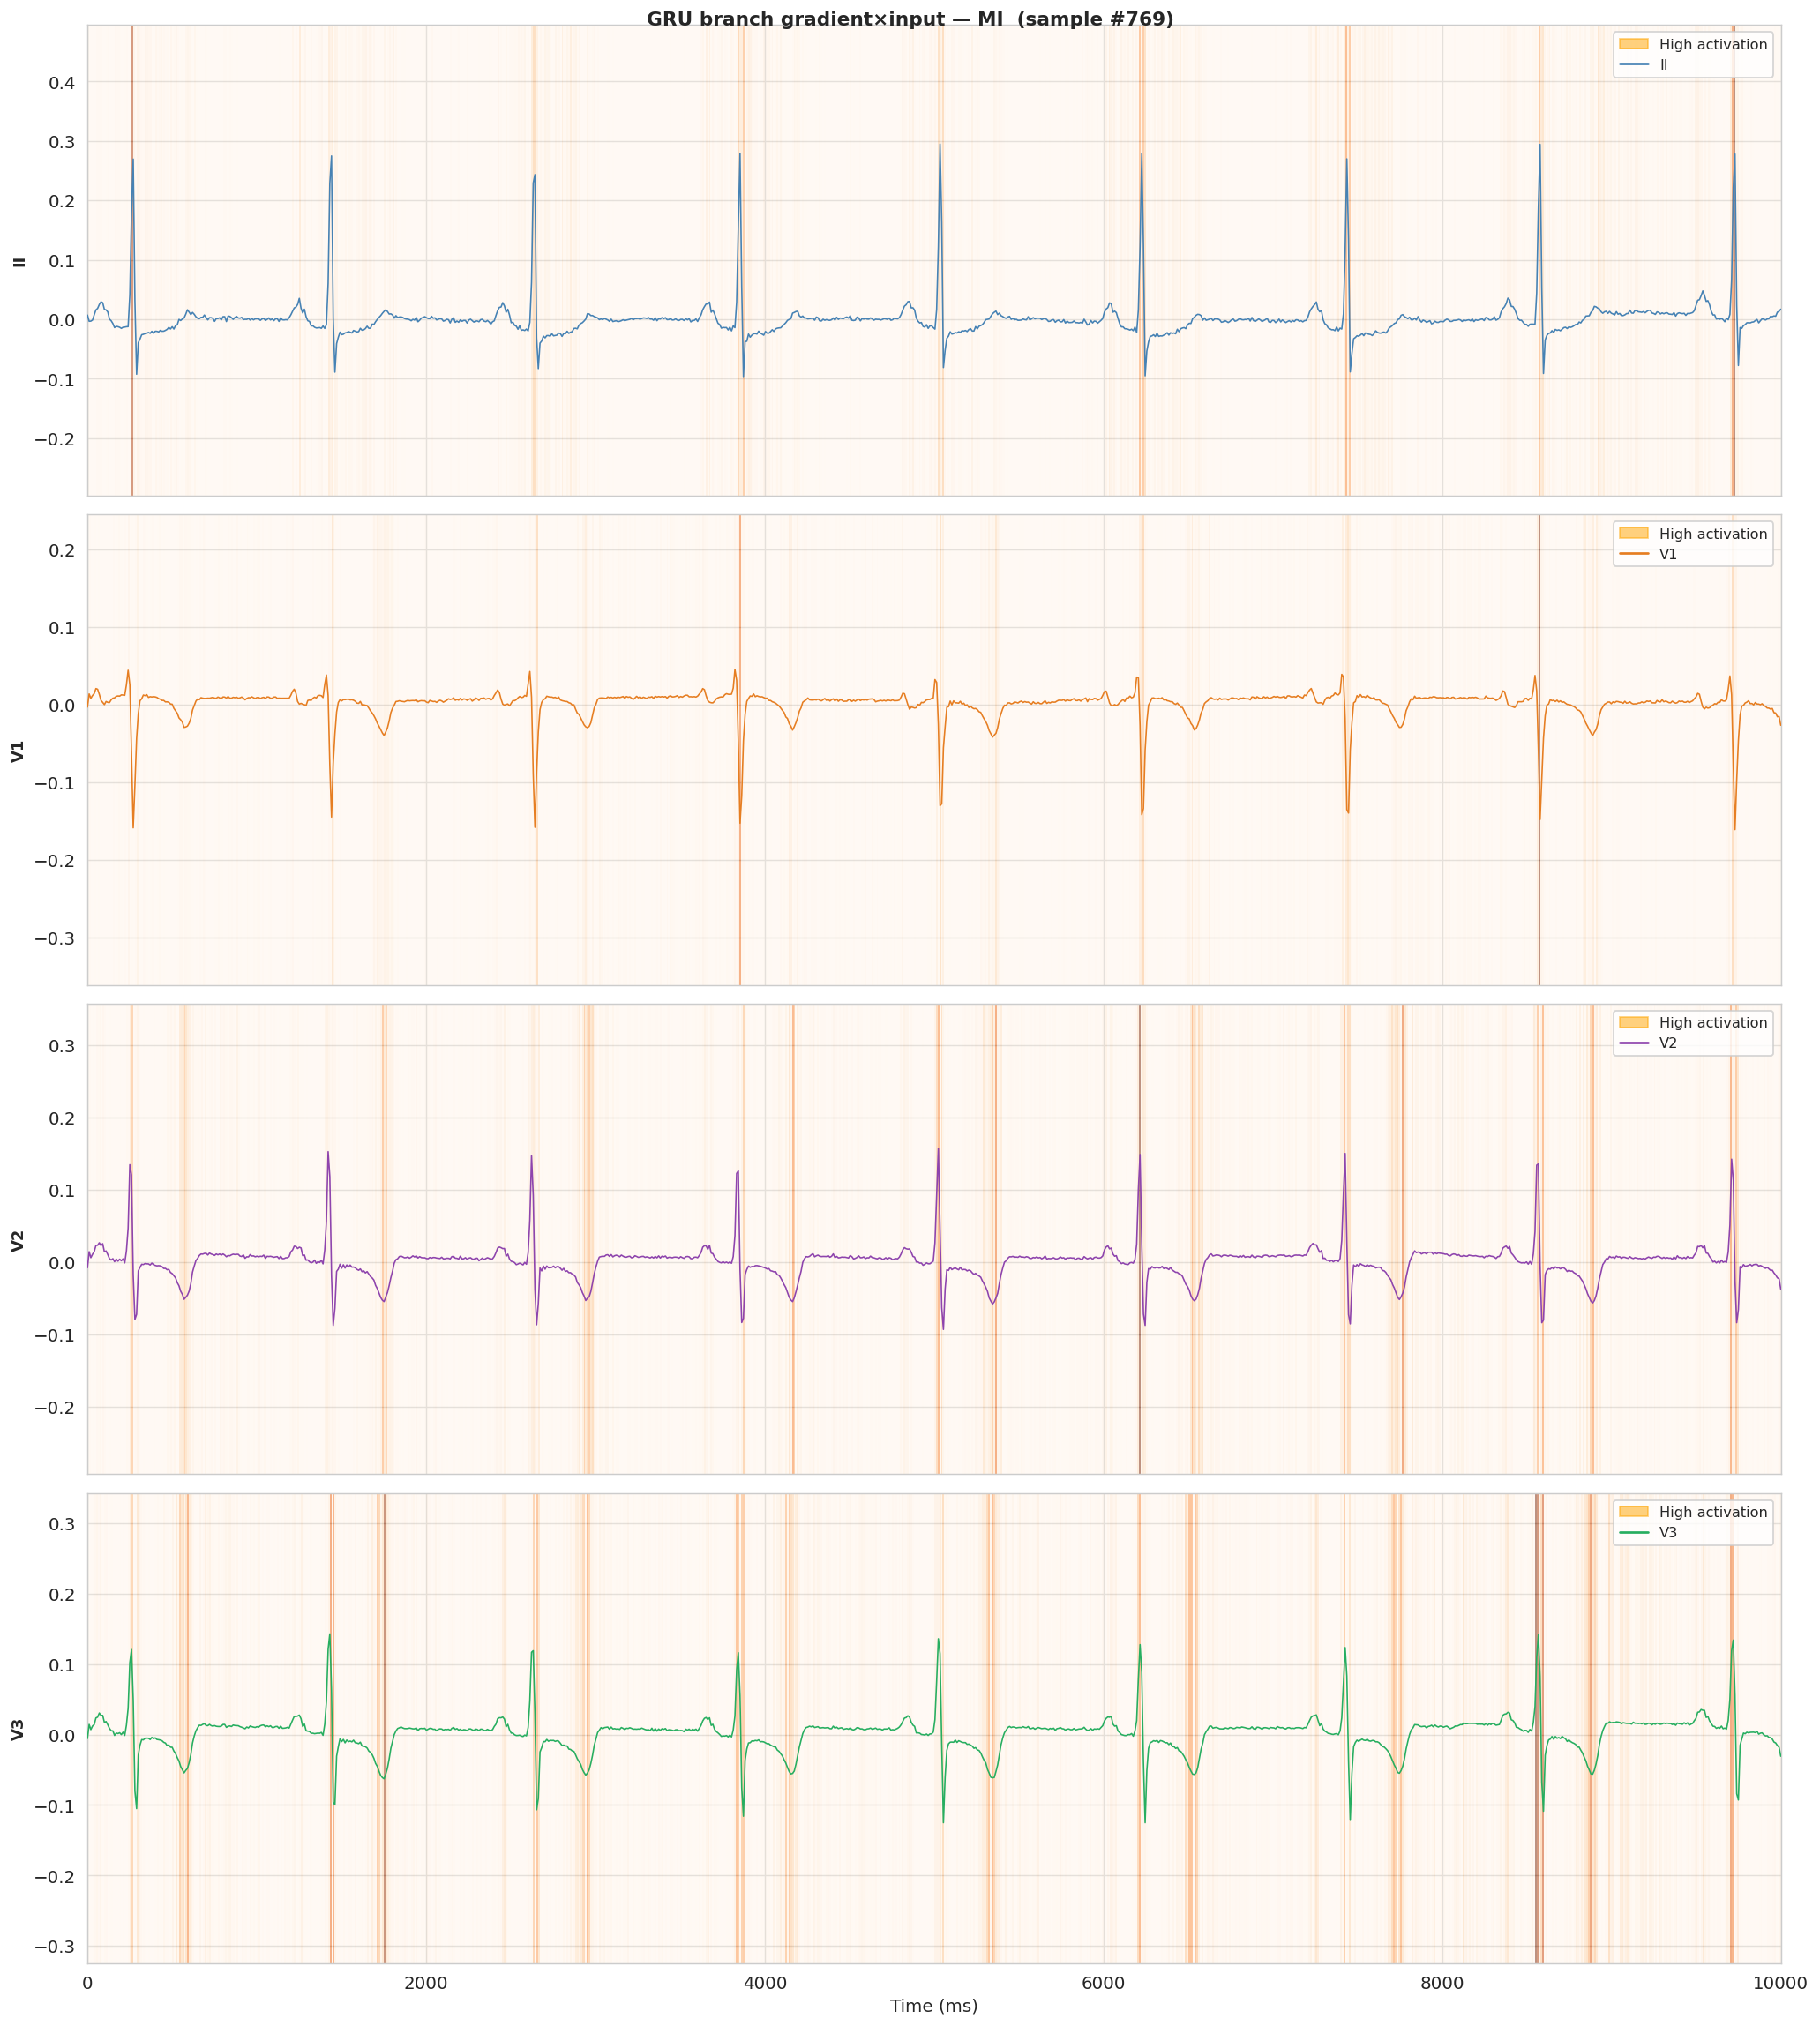

In [8]:
from scipy.signal import stft as scipy_stft
from matplotlib.collections import LineCollection
import matplotlib.patches as mpatches

def ecg_to_spec_xai(ecg, nperseg=64, noverlap=48, img_size=64):
    specs = []
    for lead in ecg:
        _, _, Z = scipy_stft(lead, nperseg=nperseg, noverlap=noverlap)
        mag = np.log1p(np.abs(Z)).astype(np.float32)
        t   = torch.tensor(mag).unsqueeze(0).unsqueeze(0)
        t   = F.interpolate(t, size=(img_size,img_size), mode="bilinear", align_corners=False)
        specs.append(t.squeeze().numpy())
    s = np.stack(specs).astype(np.float32); mn, mx = s.min(), s.max()
    return (s - mn) / (mx - mn + 1e-8)

class GradCAM2D_Fusion:
    def __init__(self, mdl, layer):
        self.mdl=mdl; self.act=None; self.grad=None
        self._fh = layer.register_forward_hook(lambda m,i,o: setattr(self,"act",o.detach()))
        self._bh = layer.register_full_backward_hook(lambda m,gi,go: setattr(self,"grad",go[0].detach()))
    def generate(self, x_raw, x_spec, ci):
        was    = self.mdl.training; self.mdl.train()
        x_raw  = x_raw.requires_grad_(False)
        x_spec = x_spec.requires_grad_(True)
        self.mdl(x_raw, x_spec)[0, ci].backward(); self.mdl.zero_grad()
        if not was: self.mdl.eval()
        w   = self.grad.mean((-2,-1), keepdim=True)
        cam = torch.relu((w * self.act).sum(1)).squeeze().cpu().numpy()
        return (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    def remove(self): self._fh.remove(); self._bh.remove()

def cam2d_to_1d(cam, out_len=1000):
    temporal = cam.mean(axis=0)
    return np.interp(np.linspace(0,1,out_len), np.linspace(0,1,len(temporal)), temporal)

def get_sample(ci, targets, probs):
    mask = targets[:, ci] == 1
    if not mask.any(): mask = np.ones(len(targets), bool)
    return np.argmax(probs[:, ci] * mask)

target_layer = model.cnn[-1][0]
grad_cam     = GradCAM2D_Fusion(model, target_layer)
TIME_MS      = np.linspace(0, 10000, 1000)

# ── GradCAM: CNN branch projected to time, overlaid on Lead-II ECG ────────────
groups = [(cls, ci, get_sample(ci, test_tgts, test_probs)) for ci, cls in enumerate(CLASS_NAMES)]
norm_mask = (test_tgts.sum(1) == 0) & ((test_probs >= 0.5).sum(1) == 0)
if norm_mask.any():
    ni = np.where(norm_mask)[0][np.argmax(1 - test_probs[norm_mask].max(1))]
    groups.append(("NORM (healthy)", -1, ni))

pcols = COLORS + ["#9b59b6"]
fig, axes = plt.subplots(len(groups), 1, figsize=(16, 4.5 * len(groups)))
if len(groups) == 1: axes = [axes]

for (cls, ci, idx), ax, col in zip(groups, axes, pcols):
    raw_t = torch.tensor(X_test_s[idx][None], dtype=torch.float32).to(DEVICE)
    spec  = ecg_to_spec_xai(X_test_s[idx])
    sp_t  = torch.tensor(spec[None]).to(DEVICE)

    if ci >= 0:
        cam2d = grad_cam.generate(raw_t, sp_t, ci)
    else:
        cams  = [grad_cam.generate(raw_t, sp_t, c) for c in range(NUM_CLASSES)]
        cam2d = np.mean(cams, 0)
        cam2d = (cam2d - cam2d.min()) / (cam2d.max() - cam2d.min() + 1e-8)

    cam1d = cam2d_to_1d(cam2d)
    sig2  = X_test_s[idx][1]
    yl, yh = sig2.min() - 0.3, sig2.max() + 0.3
    ax.pcolormesh(np.linspace(TIME_MS[0], TIME_MS[-1], 1001), [yl, yh],
                  cam1d[None], cmap="Reds", alpha=0.55, vmin=0, vmax=1, shading="flat")
    ax.plot(TIME_MS, sig2, color="steelblue", linewidth=0.9, zorder=3)
    lbl = "avg over classes" if ci < 0 else f"p={test_probs[idx,ci]:.3f}"
    ax.set_title(f"GradCAM (CNN branch) — {cls}   {lbl}   (sample #{idx})",
                 fontweight="bold", color=col, fontsize=12)
    ax.set_xlabel("Time (ms)"); ax.set_ylabel("Amplitude (mV)")
    ax.legend([mpatches.Patch(color="red", alpha=0.5), plt.Line2D([],[],color="steelblue")],
              ["High activation", "Lead II"], loc="upper right", fontsize=9)

grad_cam.remove()
plt.suptitle("GradCAM temporal saliency — Lead II ECG (CNN branch, freq. collapsed)",
             fontweight="bold", fontsize=13, y=1.002)
plt.tight_layout()
plt.savefig(CKPT_DIR/"xai_gradcam.png", bbox_inches="tight"); plt.show()

# ── GRU branch: gradient×input attribution on Lead II ─────────────────────────
def gru_attr(mdl, x_raw, x_spec, ci, device=DEVICE):
    xr = x_raw.to(device).requires_grad_(True)
    xs = x_spec.to(device).requires_grad_(False)
    mdl.train(); mdl(xr, xs)[0, ci].backward(); mdl.zero_grad(); mdl.eval()
    return (xr.grad * x_raw.to(device)).abs().squeeze(0).cpu().numpy()

demo_ci  = 0
demo_idx = get_sample(demo_ci, test_tgts, test_probs)
raw_t    = torch.tensor(X_test_s[demo_idx][None], dtype=torch.float32)
sp_t     = torch.tensor(ecg_to_spec_xai(X_test_s[demo_idx])[None])
print(f"GRU attribution for {CLASS_NAMES[demo_ci]} (sample #{demo_idx}) ...")
attr = gru_attr(model, raw_t, sp_t, demo_ci)

lead_subset = [1, 6, 7, 8]   # II, V1, V2, V3
fig, axes = plt.subplots(len(lead_subset), 1, figsize=(16, 4.5 * len(lead_subset)), sharex=True)
pcols2 = ["steelblue", "#e67e22", "#8e44ad", "#27ae60"]
for ax, li, col in zip(axes, lead_subset, pcols2):
    a    = attr[li]; sig = X_test_s[demo_idx][li]
    n_a  = (a - a.min()) / (a.max() - a.min() + 1e-8)
    yl, yh = sig.min() - 0.2, sig.max() + 0.2
    ax.pcolormesh(np.linspace(TIME_MS[0], TIME_MS[-1], 1001), [yl, yh],
                  n_a[None], cmap="Oranges", alpha=0.5, shading="flat", vmin=0, vmax=1)
    ax.plot(TIME_MS, sig, color=col, linewidth=0.9, zorder=3)
    ax.set_ylabel(LEAD_NAMES[li], fontsize=10, fontweight="bold")
    ax.legend([mpatches.Patch(color="orange", alpha=0.5), plt.Line2D([],[],color=col)],
              ["High activation", LEAD_NAMES[li]], loc="upper right", fontsize=9)
axes[-1].set_xlabel("Time (ms)")
plt.suptitle(f"GRU branch gradient×input — {CLASS_NAMES[demo_ci]}  (sample #{demo_idx})",
             fontweight="bold", fontsize=12)
plt.tight_layout()
plt.savefig(CKPT_DIR/"xai_gru_attribution.png", bbox_inches="tight"); plt.show()


## 8 · Summary

In [ ]:

print("="*60)
print(f"  SUMMARY  |  {model.__class__.__name__}")
print("="*60)
print_metrics(test_m_tun, "Test set — tuned thresholds")
print()
for f in sorted(CKPT_DIR.iterdir()):
    if f.is_file(): print(f"  {f.name:<45} {f.stat().st_size/1024:6.1f} KB")


  SUMMARY  |  GRU_2DCNN_Fusion

───────────────────────────────────────────────────────
  Test set — tuned thresholds
───────────────────────────────────────────────────────
Class   Sensitivity  Specificity   Accuracy       F1
────────────────────────────────────────────────────
MI           0.8095       0.9493     0.9381   0.6777
STTC         0.7655       0.8247     0.8034   0.7368
CD           0.8336       0.7904     0.8060   0.7560
HYP          0.7857       0.6650     0.7103   0.6705
────────────────────────────────────────────────────
Macro        0.7986       0.8074     0.8145   0.7103
  Macro AUC: 0.8825

  bar_metrics.png                                 48.1 KB
  best_model.pt                                 3902.2 KB
  confusion_matrices.png                          39.6 KB
  metrics_heatmap.png                             55.4 KB
  threshold_curves.png                            83.6 KB
  training_curves.png                             48.6 KB
  xai_gradcam.png                

: 